<a href="https://colab.research.google.com/github/tacinunesc/Aula_1_Gemeos_Digitais_UniFacens/blob/main/aula3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Importando Bibliotecas**

Referências:
https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python

https://medium.com/@ugursavci/complete-exploratory-data-analysis-using-python-9f685d67d1e4

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

Dataset: https://www.transparencia.sp.gov.br/home/Remuneracao

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# **Etapa 1- Carregando os dados**

In [2]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving RemuneracaoAtivos.csv to RemuneracaoAtivos.csv


**Salvando os dados em um dataframe**

In [3]:
df = pd.read_csv('RemuneracaoAtivos.csv', encoding='latin-1', sep=';') #salvando o dataset em um dataframe

**Ok, e agora o que vamos fazer com isso?**

In [ ]:
df.info()

Veja o problema, as variáveis numéricas estão como objeto!

**Antes de olhar vamos realizar uma anonimização (não vamos expor nomes nas análises)**

Solução 1:

In [5]:
import random

primeiros_nomes = ["Ana", "Bruno", "Carlos", "Daniela", "Eduardo", "Fernanda",
                   "Gabriel", "Helena", "Igor", "Juliana", "Lucas", "Mariana"]

sobrenomes = ["Silva", "Souza", "Oliveira", "Santos", "Pereira",
              "Costa", "Rodrigues", "Almeida", "Nascimento"]

def gerar_nome():
    return f"{random.choice(primeiros_nomes)} {random.choice(sobrenomes)}"

df['NOME'] = [gerar_nome() for _ in range(len(df))]

**Vamos ver o dataset agora:**

In [ ]:
df.head() #visualizando cabeçalho do dataset

**Conhecendo mais sobre o dataset**

In [ ]:
df.head(10) # Visualizando primeiras 10 linhas

In [ ]:
df.tail(5)  # Visualizando ultimas cinco colunas

In [ ]:
df

# **Etapa 2 - Limpeza dos dados**

Nós vamos remover caracteres complexos dos nomes das colunas

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

**Vamos verificar nossos dados** - **lembre-se:** *nunca confiar!*

---



In [11]:
# Verificando dados
print ("Tabela 1 - Verificação de dados")
print(df.info())
print("\n") #paragráfo entre os resultados

# Verificando se há algum valor vazio
print ("Tabela 2 - Verificação de dados vazios")
print(df.isna().any())
print("\n")

# Verificando quantidade de dados vazios
print ("Tabela 3 - Verificação de quantidade de dados vazios")
print(df.isna().sum())
print("\n")

Tabela 1 - Verificação de dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501205 entries, 0 to 501204
Data columns (total 11 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   nome                                     501205 non-null  object
 1   cargo                                    501205 non-null  object
 2   orgão                                    501205 non-null  object
 3   remuneração_do_mês                       501205 non-null  object
 4   férias_e_13º_salário                     501205 non-null  object
 5   pagamentos_eventuais                     501205 non-null  object
 6   licença_prêmio_indenizada                501205 non-null  object
 7   abono_permanência_&_outras_indenizações  501205 non-null  object
 8   redutor_salarial                         501205 non-null  object
 9   total_liquído_r$                         501205 non-null  object
 10  grupo       

**Os números que observamos estão sendo entendidos como texto, vamos arrumar.**

In [12]:
# Selecionando as colunas numéricas
colunas_numericas = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

In [13]:
# Convertendo texto para números decimais, removendo espaços e mudando de , para . o separador de decimal
def converter_moeda(coluna):
    return (
        coluna.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

In [14]:
#Aplicando para todas as colunas numéricas
for col in colunas_numericas:
    df[col] = converter_moeda(df[col])

In [15]:
df.dtypes

,0
nome,object
cargo,object
orgão,object
remuneração_do_mês,float64
férias_e_13º_salário,float64
pagamentos_eventuais,float64
licença_prêmio_indenizada,float64
abono_permanência_&_outras_indenizações,float64
redutor_salarial,float64
total_liquído_r$,float64


**Limpeza do dataset**

**Removendo colunas do dataset**

Pode ser interessante remover colunas do dataset para facilitar a visualização gráfica dos dados, ou para a realização de análises. Nesse caso poderíamos remover a coluna grupo, pois ela não revela muita coisa.

In [ ]:
df = df.drop(['grupo'], axis=1)
df.head(5)

**Verificando e removendo dados duplicados**

In [17]:
#Contabilizando linhas
df.count()

,0
nome,501205
cargo,501205
orgão,501205
remuneração_do_mês,501205
férias_e_13º_salário,501205
pagamentos_eventuais,501205
licença_prêmio_indenizada,501205
abono_permanência_&_outras_indenizações,501205
redutor_salarial,501205
total_liquído_r$,501205


In [18]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (31603, 10)


**Está aparecendo que temos mais de 34000 dados dpulicados! Será que é isso mesmo?**

In [ ]:
duplicate_rows_df.head()

**Olha aqui o problema, nós randomizamos os nomes!**

In [20]:
df.groupby('nome').size().sort_values(ascending=False).head()

,0
nome,
Carlos Souza,4836
Igor Souza,4813
Igor Oliveira,4794
Fernanda Silva,4787
Eduardo Santos,4763


# Solução

In [21]:
df['id'] = range(len(df))
#Agora sim, cada linha uma identidade

Vamos testar:

In [22]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 11)


Não vamos remover, mas seguem os comandos caso precisem no futuro:

In [ ]:
# Removendo dados duplicados
df = df.drop_duplicates()
df.head(5)

In [24]:
# Contabilizando dados após verificação de dados duplicados
df.count()

,0
nome,501205
cargo,501205
orgão,501205
remuneração_do_mês,501205
férias_e_13º_salário,501205
pagamentos_eventuais,501205
licença_prêmio_indenizada,501205
abono_permanência_&_outras_indenizações,501205
redutor_salarial,501205
total_liquído_r$,501205


**Dados faltantes e nulos**

Nesse exemplo iremos apenas detectar se temos valores ausentes e nulos pois eles podem aparecer no dataset.

Existem abordagens onde poderíamos estimar os valores, substituí-los pela média ou mediana da coluna, além de utilizar outras abordagens para estima-los, com base em teoria de probabilidade. Mas cuidado extremo ao fazer isso, saiba o que você está fazendo, pois estará alterando o dataset com novos dados.

Sempre busque critérios para remoção desses valores, nesse caso não temos, o gorverno do Estado fez um bom trabalho.

In [25]:
# Contando vazios novamente
print(df.isnull().sum())

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
id                                         0
dtype: int64


In [26]:
# Removendo vazios
df = df.dropna()
print(df.isnull().sum()) # Recontando vazios

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
id                                         0
dtype: int64


# **Etapa 3 - Realização da EDA**

**Realização das análises univariadas**

1. *Estatística descritiva*
2. *Histograma*
3. *Boxplot*
4. *Barplot*

# **1. Estatística descritiva**

Em phyton a função describe() fornece um resumo estatístico. Com isso é possível verificar de forma geral o comportameento da dua amostra, potencial existência de outliers, erros de entrada de dados, e a distribuição dos dados, se são normalmente distribuídos ou assimétricos para a esquerda/direita.

A função describe() fornece um resumo estatístico dos dados numéricos, como int e float."

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,501205.0,7395.383513,5742.723382,0.00,4480.09,6536.56,8502.63,226729.46
férias_e_13º_salário,501205.0,357.098331,1719.118963,-12100.51,0.00,0.00,0.00,124149.68
pagamentos_eventuais,501205.0,1320.405757,3465.135946,-15765.32,0.00,0.00,474.33,289367.45
licença_prêmio_indenizada,501205.0,60.008879,868.904451,-30409.36,0.00,0.00,0.00,46366.18
abono_permanência_&_outras_indenizações,501205.0,491.915271,2396.848645,-9822.86,0.00,19.54,493.35,332879.66
redutor_salarial,501205.0,-169.074473,2487.262187,-192715.71,0.00,0.00,0.00,93.32
total_liquído_r$,501205.0,6453.733171,6085.016297,-40292.39,3275.15,5032.97,7973.62,390420.48
id,501205.0,250602.000000,144685.565172,0.00,125301.00,250602.00,375903.00,501204.00


Porém, podemos ter a necessidade de consultar os parametros de estatística descritiva de forma isolada, ou adicionar mais parametros na analise, para isso podemos utilizar outra abordagem:

Podemos utilizar:
- statistics_summary['median']: Adiciona a mediana das colunas.
- statistics_summary['mode']: Adiciona a moda.
- statistics_summary['range']: Calcula o intervalo.
- statistics_summary['cv']: Calcula o coeficiente de variação (CV).
- statistics_summary['skewness']: Calcula a assimetria.
- statistics_summary['kurtosis']: Calcula a curtose.
- statistics_summary['sem']: Calcula o erro padrão da média (SEM).
- statistics_summary['Q1']: Adiciona o primeiro quartil (25º percentil).
- statistics_summary['Q3']: Adiciona o terceiro quartil (75º percentil).
- statistics_summary['IQR']: Calcula o intervalo interquartil, que é a diferença entre o terceiro e o primeiro quartil.

**Atenção:**
- *Importação Necessária*: Não se esqueça de importar as funções necessárias: from scipy.stats import skew, kurtosis.
- *Filtro de Dados*: É necessário garantir que o dataset não contenha dados não numéricos no DataFrame. Filtre para incluir apenas colunas numéricas.

Essa abordagem fornece um resumo completo das estatísticas do seu DataFrame df, incluindo medidas adicionais que podem ser úteis para uma análise mais aprofundada.


In [28]:
from scipy.stats import skew, kurtosis

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Calculando estatísticas básicas
statistics_summary = numeric_df.describe().T

# Calculando estatísticas adicionais
statistics_summary['median'] = numeric_df.median()
statistics_summary['mode'] = numeric_df.mode().iloc[0]
statistics_summary['range'] = numeric_df.max() - numeric_df.min()
statistics_summary['cv'] = statistics_summary['std'] / statistics_summary['mean']  # Coeficiente de variação
statistics_summary['skewness'] = numeric_df.apply(lambda x: skew(x.dropna()))
statistics_summary['kurtosis'] = numeric_df.apply(lambda x: kurtosis(x.dropna()))
statistics_summary['sem'] = numeric_df.sem()  # Erro padrão da média

# Calculando quartis e intervalo interquartil
quartiles = numeric_df.quantile([0.25, 0.75])
statistics_summary['Q1'] = quartiles.loc[0.25]
statistics_summary['Q3'] = quartiles.loc[0.75]
statistics_summary['IQR'] = statistics_summary['Q3'] - statistics_summary['Q1']

# Visualizando o resumo das estatísticas
statistics_summary = statistics_summary[['count', 'mean', 'std', 'median', 'mode', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'cv', 'skewness', 'kurtosis', 'sem']]

# Formatando todas as colunas para exibir duas casas decimais
statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")

# Exibindo o resumo das estatísticas
statistics_summary

/tmp/ipykernel_1070/440432963.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")


,count,mean,std,median,mode,min,max,range,Q1,Q3,IQR,cv,skewness,kurtosis,sem
remuneração_do_mês,501205.00,7395.38,5742.72,6536.56,7791.00,0.00,226729.46,226729.46,4480.09,8502.63,4022.54,0.78,4.98,59.76,8.11
férias_e_13º_salário,501205.00,357.10,1719.12,0.00,0.00,-12100.51,124149.68,136250.19,0.00,0.00,0.00,4.81,13.03,369.62,2.43
pagamentos_eventuais,501205.00,1320.41,3465.14,0.00,0.00,-15765.32,289367.45,305132.77,0.00,474.33,474.33,2.62,6.36,142.18,4.89
licença_prêmio_indenizada,501205.00,60.01,868.90,0.00,0.00,-30409.36,46366.18,76775.54,0.00,0.00,0.00,14.48,21.84,670.57,1.23
abono_permanência_&_outras_indenizações,501205.00,491.92,2396.85,19.54,0.00,-9822.86,332879.66,342702.52,0.00,493.35,493.35,4.87,27.57,1861.02,3.39
redutor_salarial,501205.00,-169.07,2487.26,0.00,0.00,-192715.71,93.32,192809.03,0.00,0.00,0.00,-14.71,-21.15,677.23,3.51
total_liquído_r$,501205.00,6453.73,6085.02,5032.97,5910.33,-40292.39,390420.48,430712.87,3275.15,7973.62,4698.47,0.94,6.53,121.58,8.60
id,501205.00,250602.00,144685.57,250602.00,0.00,0.00,501204.00,501204.00,125301.00,375903.00,250602.00,0.58,0.00,-1.20,204.37


# **2. Analisando a distribuição de frequência das variáveis (histograma)**

array([[<Axes: title={'center': 'remuneração_do_mês'}>,
        <Axes: title={'center': 'férias_e_13º_salário'}>,
        <Axes: title={'center': 'pagamentos_eventuais'}>],
       [<Axes: title={'center': 'licença_prêmio_indenizada'}>,
        <Axes: title={'center': 'abono_permanência_&_outras_indenizações'}>,
        <Axes: title={'center': 'redutor_salarial'}>],
       [<Axes: title={'center': 'total_liquído_r$'}>,
        <Axes: title={'center': 'id'}>, <Axes: >]], dtype=object)

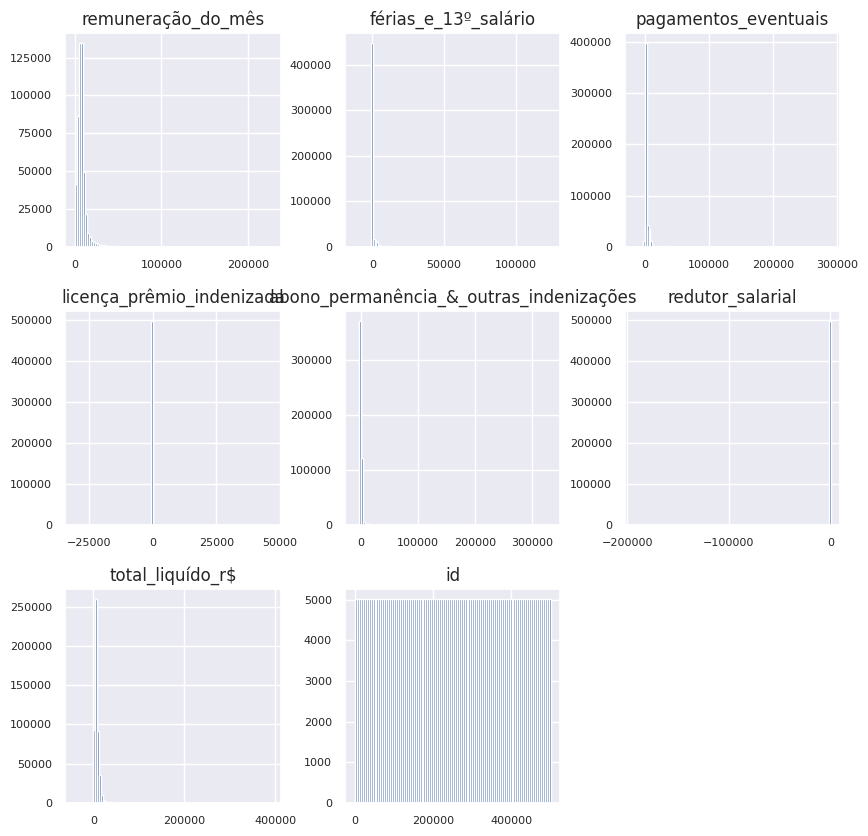

In [29]:
numeric_df.hist(figsize=(10, 10), bins=100, xlabelsize=8, ylabelsize=8)

2.1. Gerando histogramas utilizando a Matplotlib

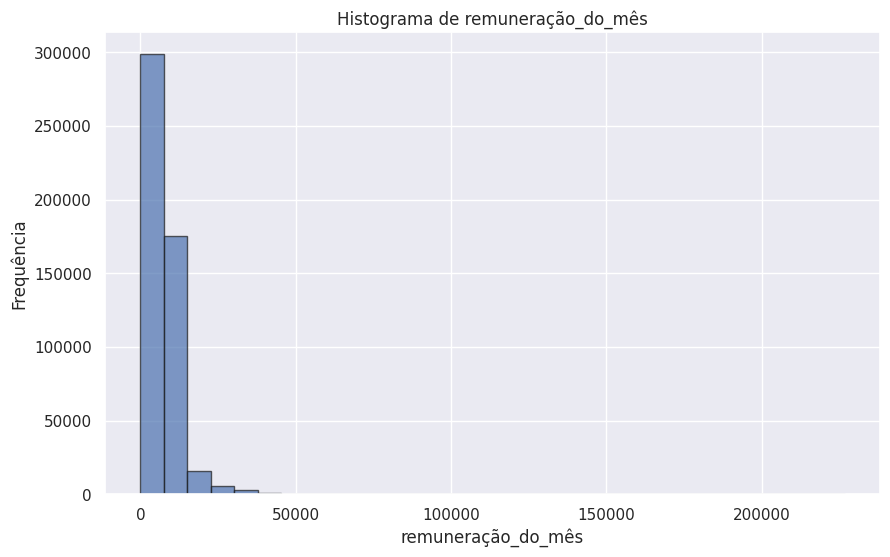

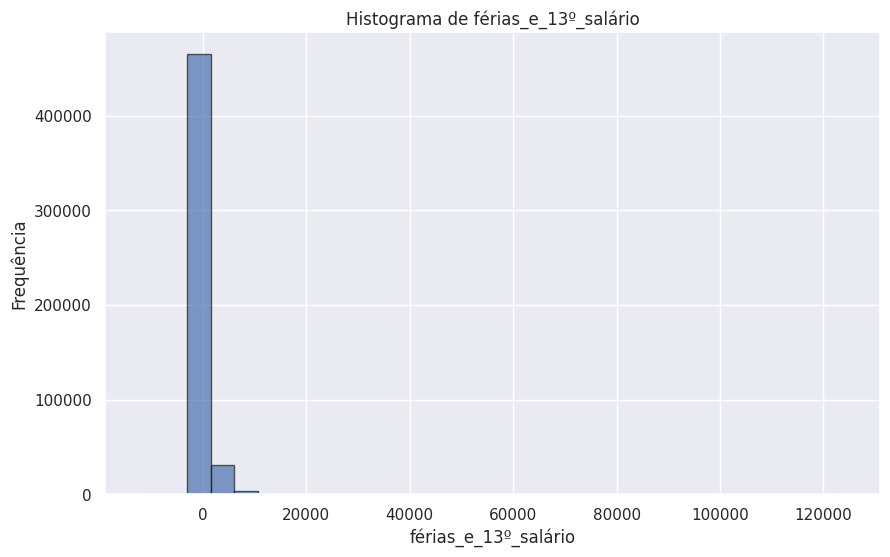

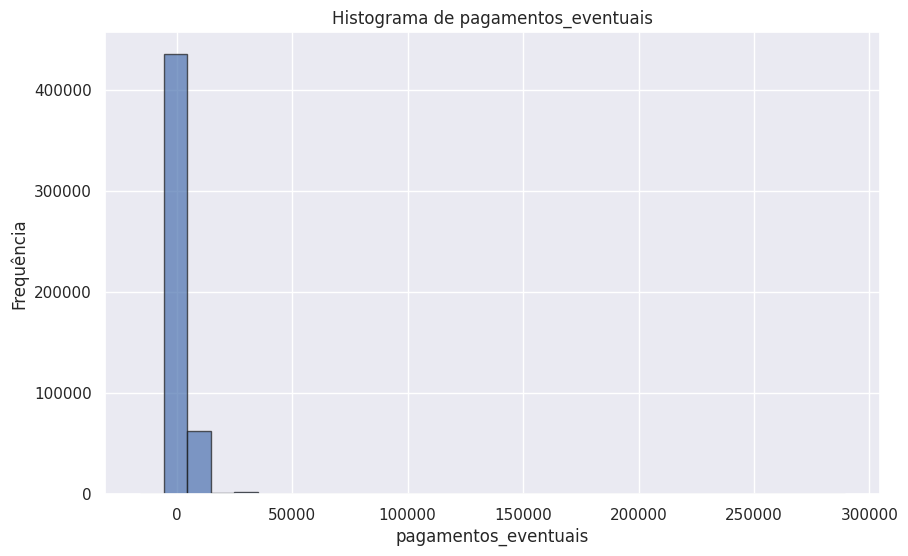

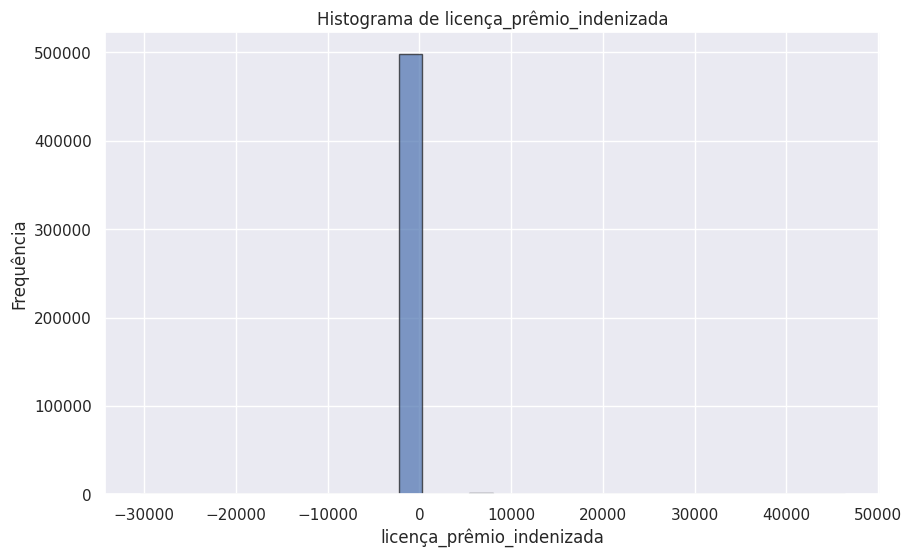

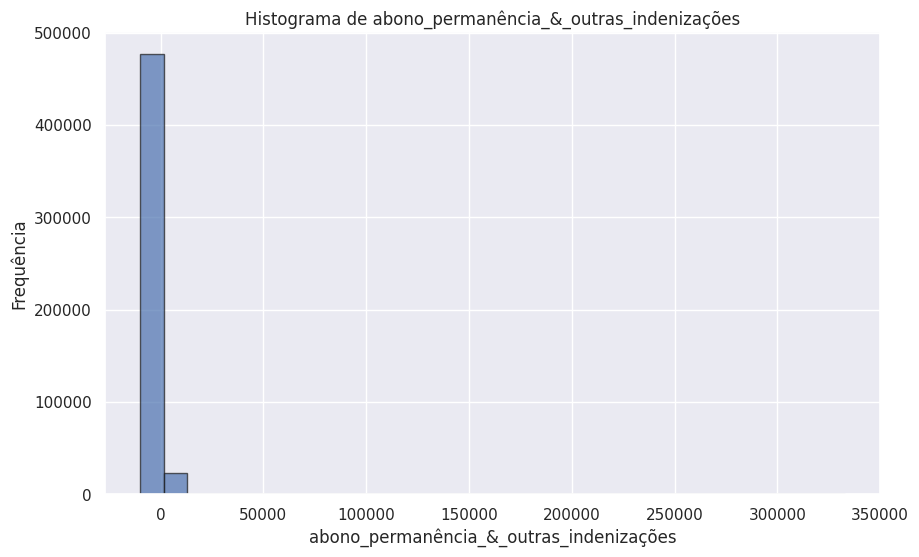

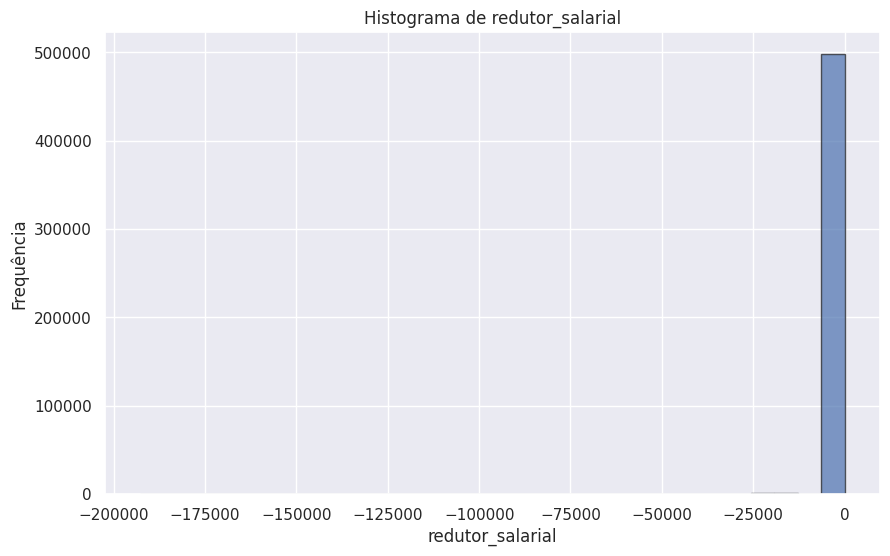

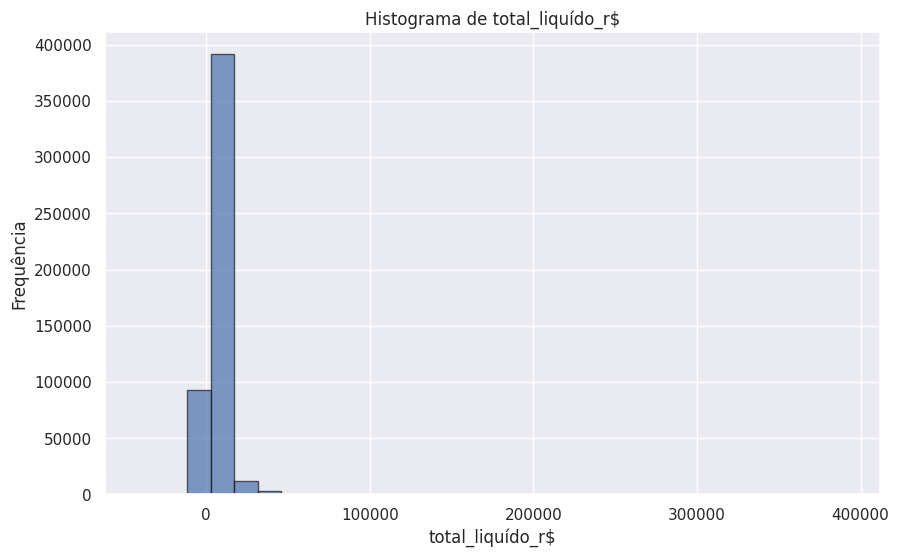

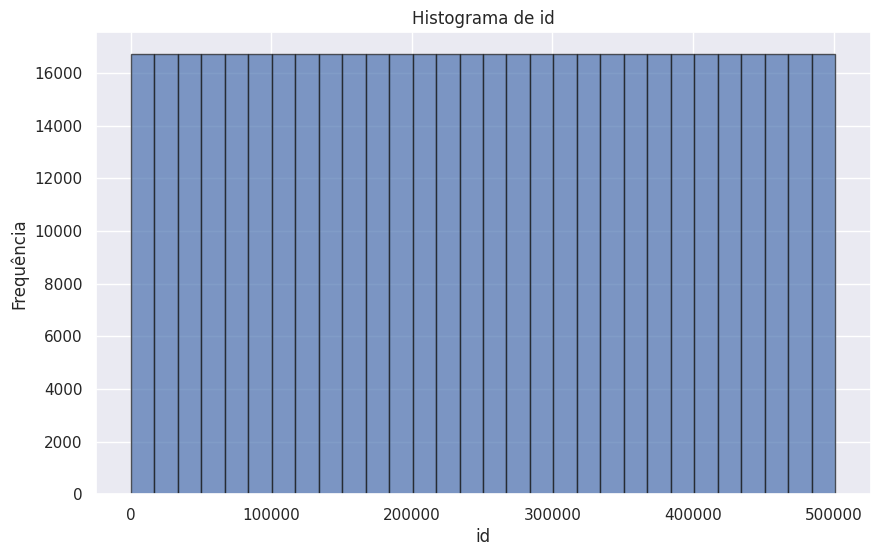

In [30]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

Gerando histogramas utilizando a Seaborn

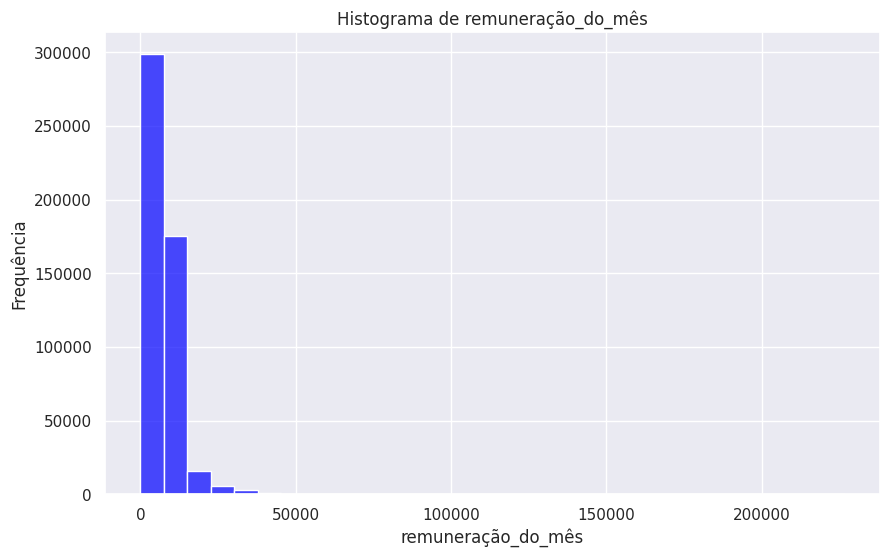

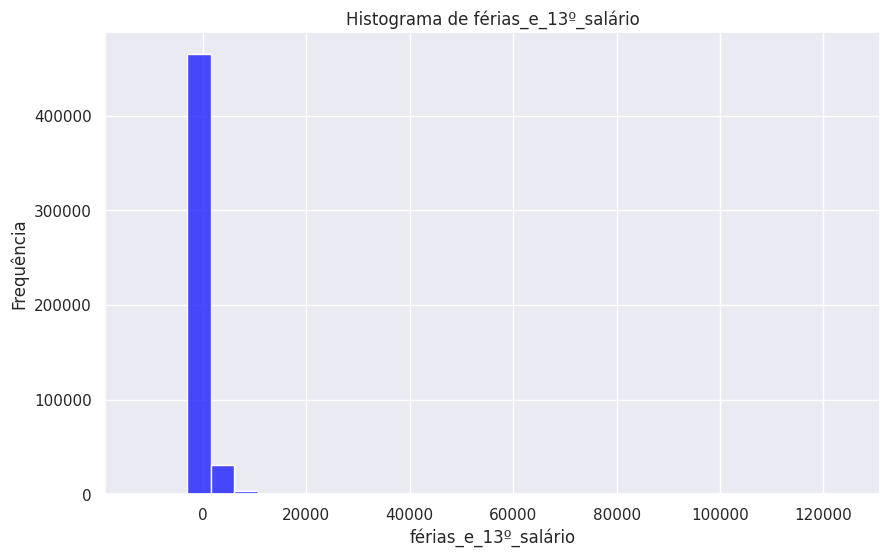

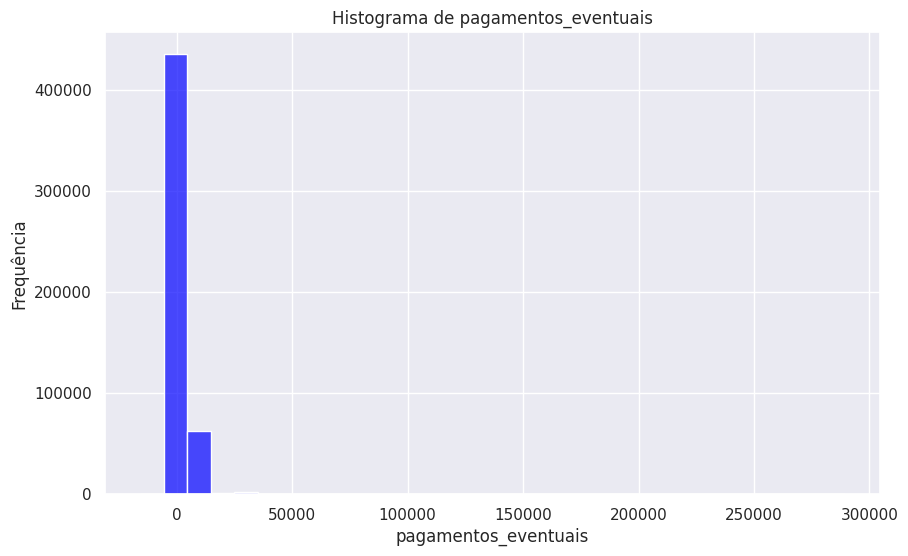

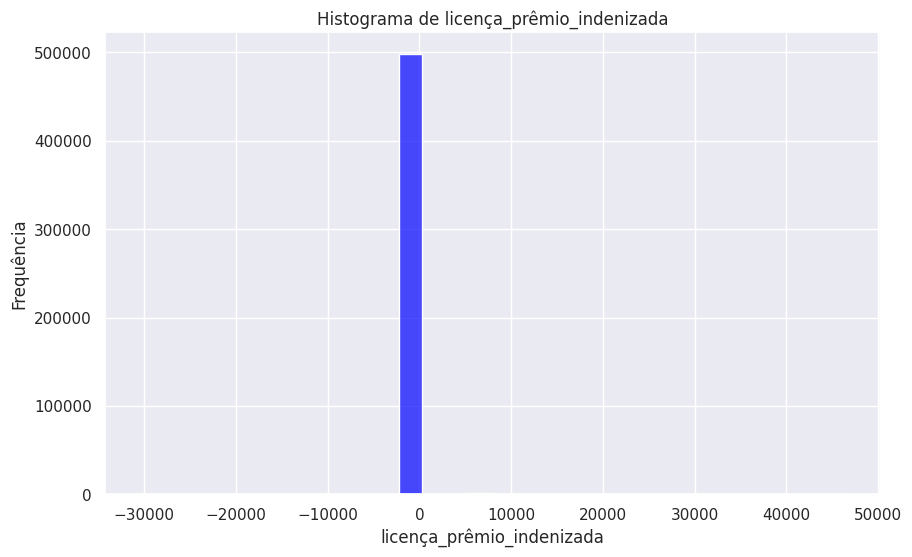

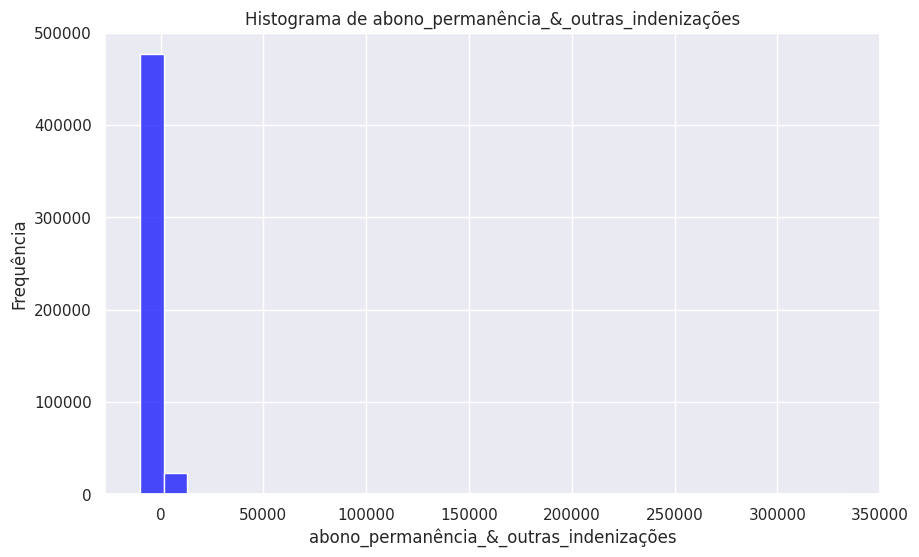

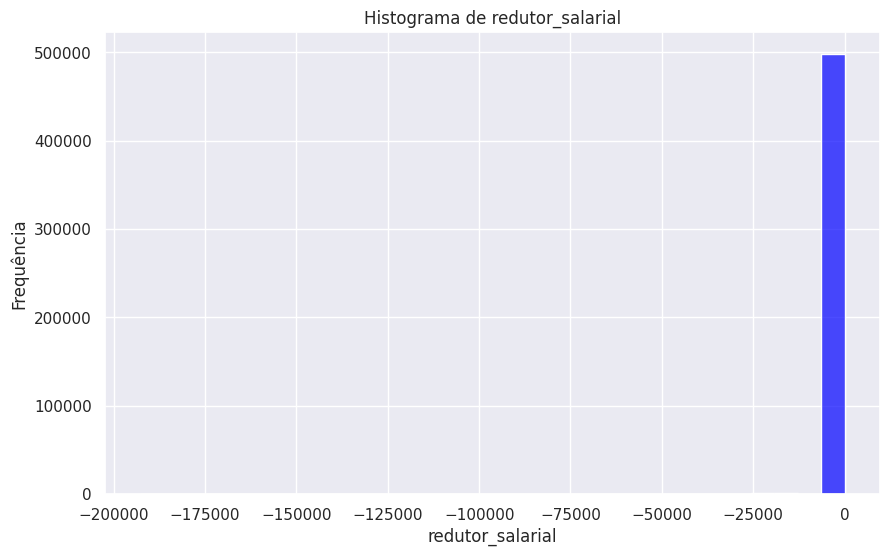

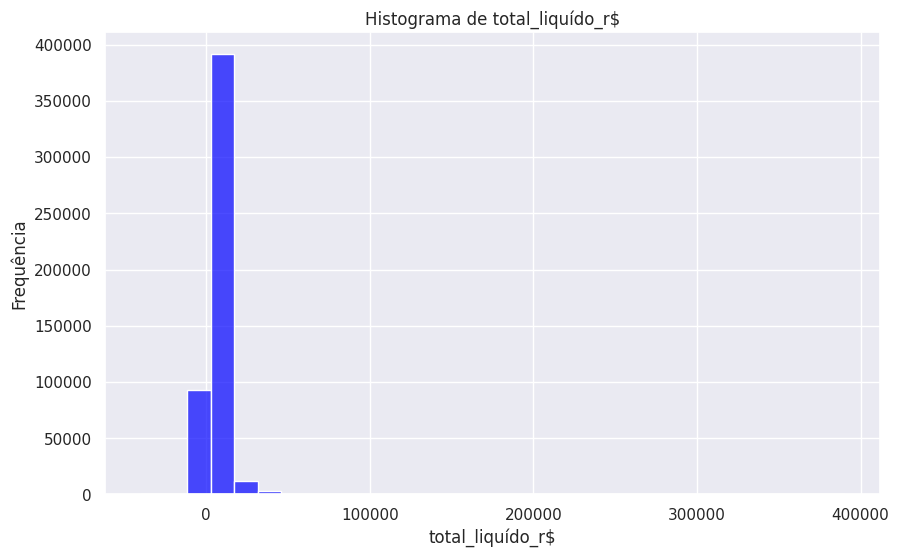

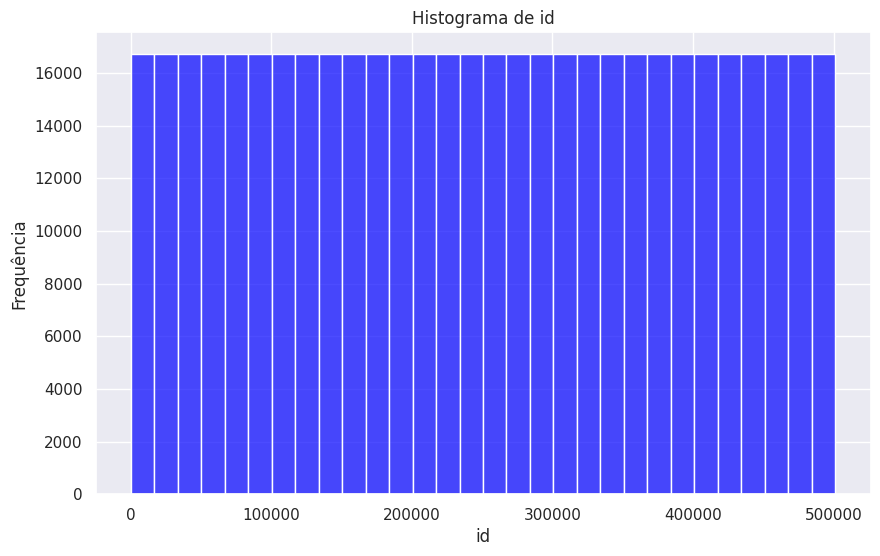

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, color='blue', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.hist(): Cria um histograma básico usando matplotlib. O parâmetro bins define o número de intervalos no histograma, e edgecolor define a cor da borda dos bins.
- sns.histplot(): Cria um histograma usando seaborn, que também pode incluir uma estimativa da densidade de kernel (kde=True) se você desejar. O parâmetro color define a cor dos bins.
- O parâmetro alpha em visualizações como histogramas e gráficos de dispersão controla a transparência das barras ou pontos. O valor de alpha varia de 0 a 1, onde:
alpha = 0: Totalmente transparente.
alpha = 1: Totalmente opaco (sem transparência).

Ambos os métodos permitem visualizar a distribuição das variáveis numéricas no seu DataFrame. Ajuste o número de bins e outras opções conforme necessário para obter a visualização desejada.

Observando em uma linha

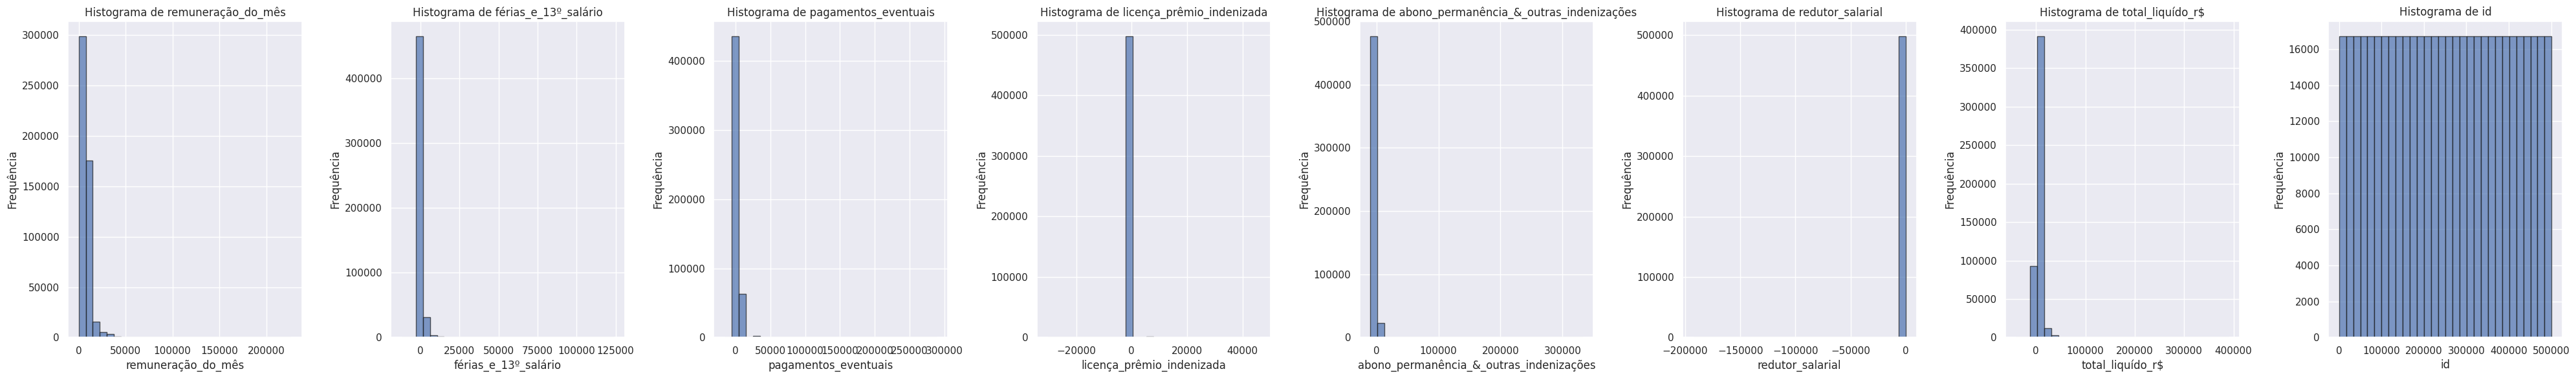

In [32]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

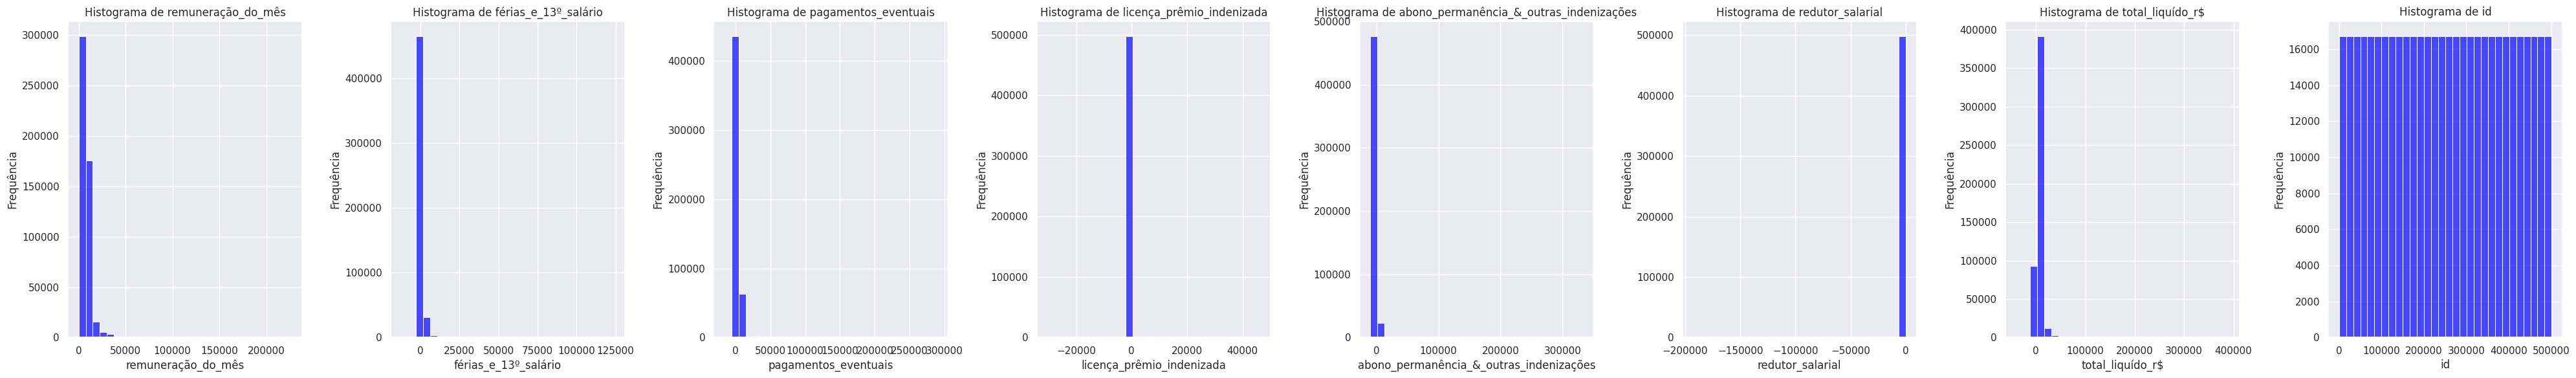

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, ax=ax, color='blue', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **3. Boxplots**

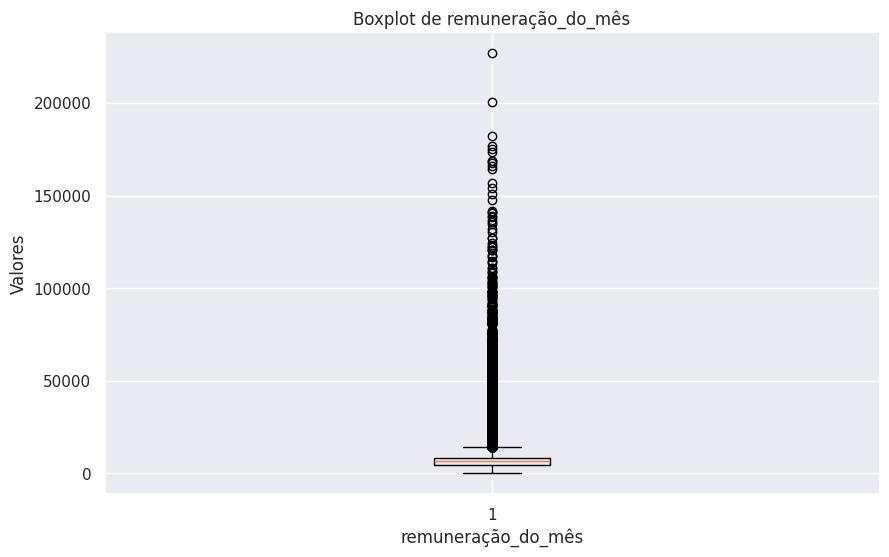

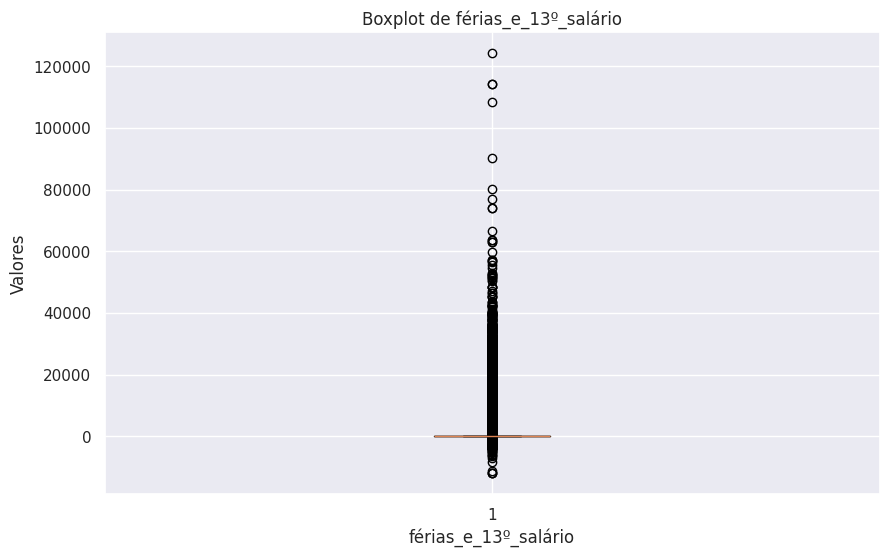

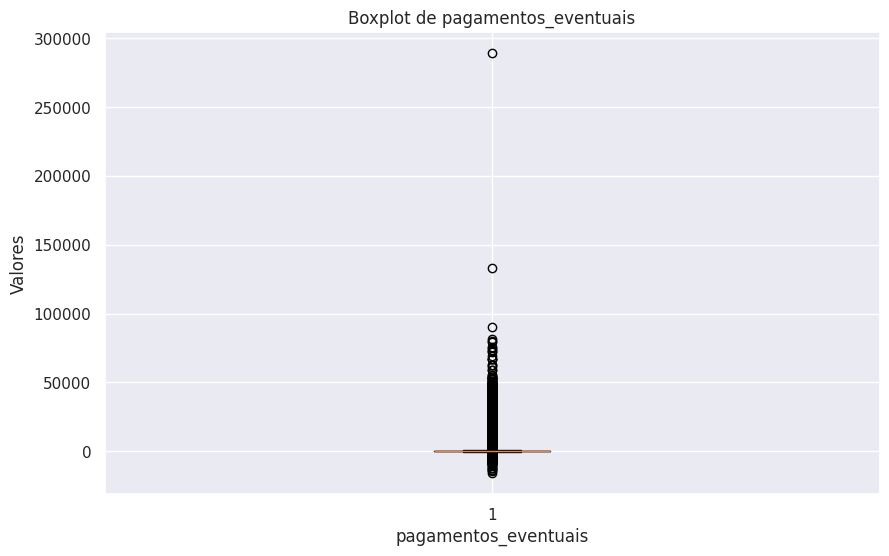

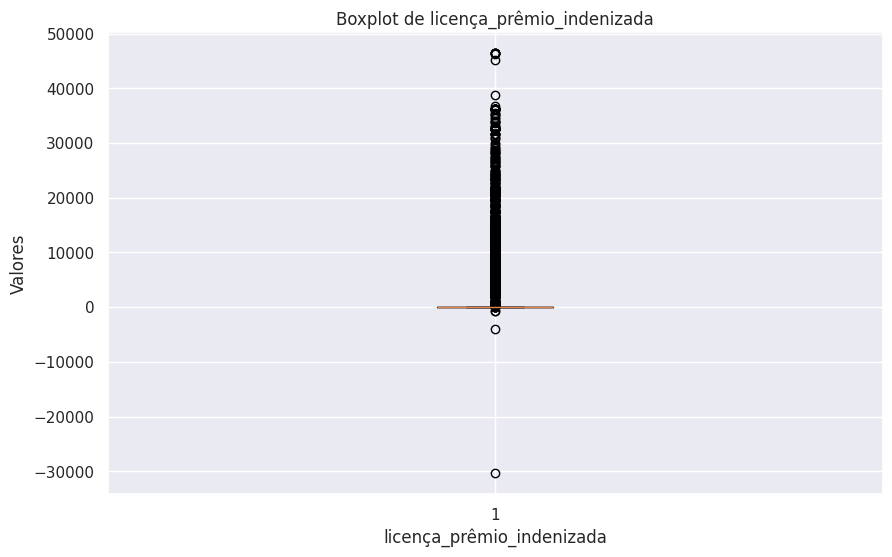

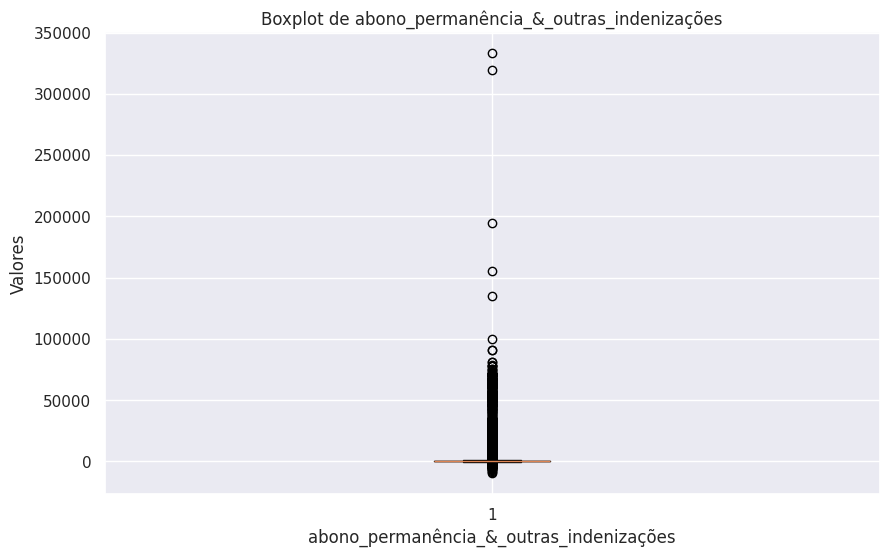

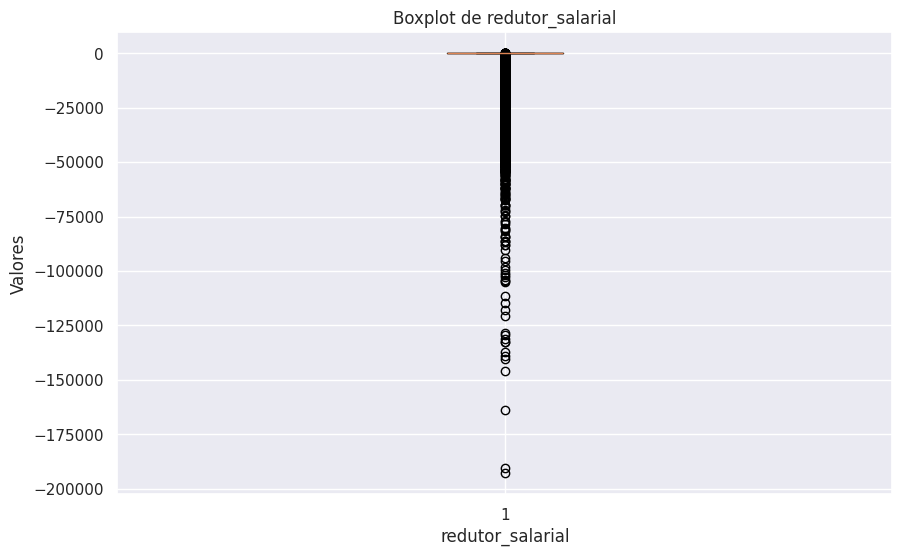

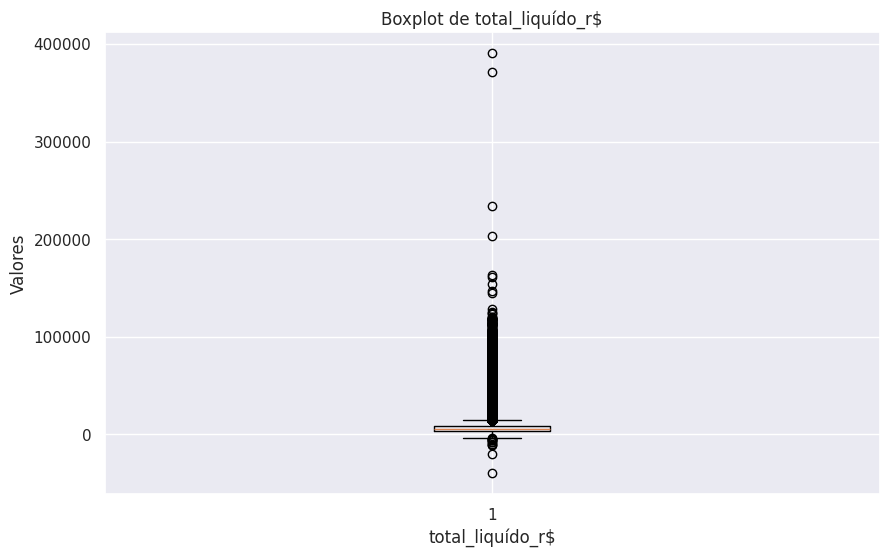

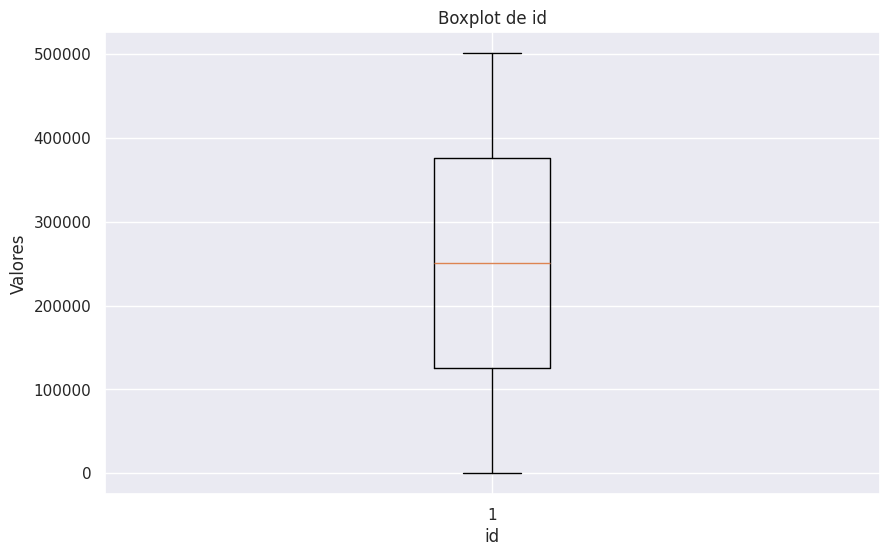

In [34]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(numeric_df[column].dropna())
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.ylabel('Valores')
    plt.grid(True)
    plt.show()

**Boxplots com Seaborn**

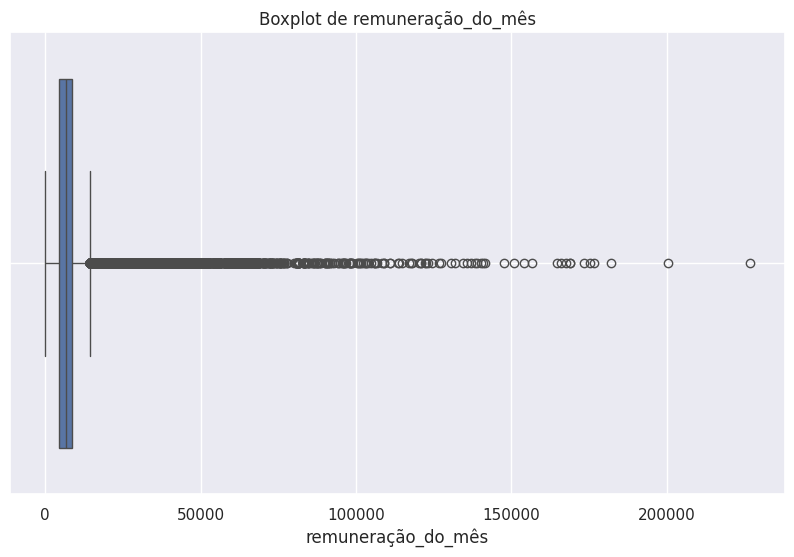

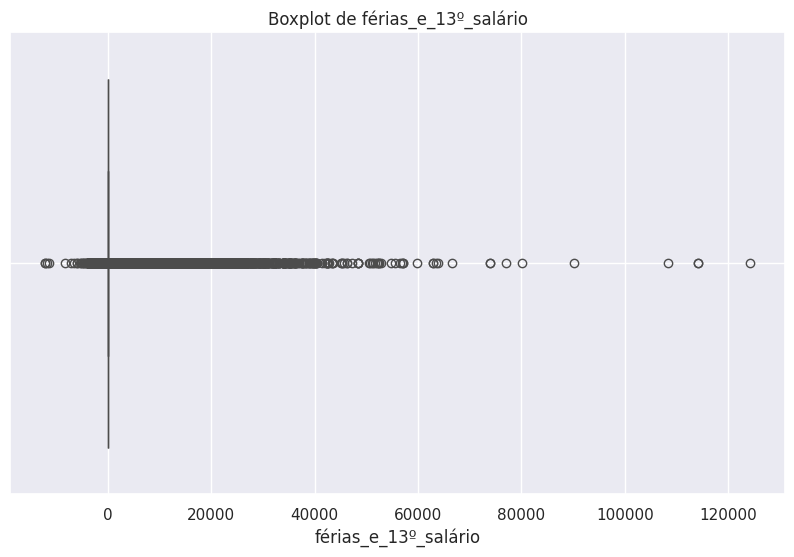

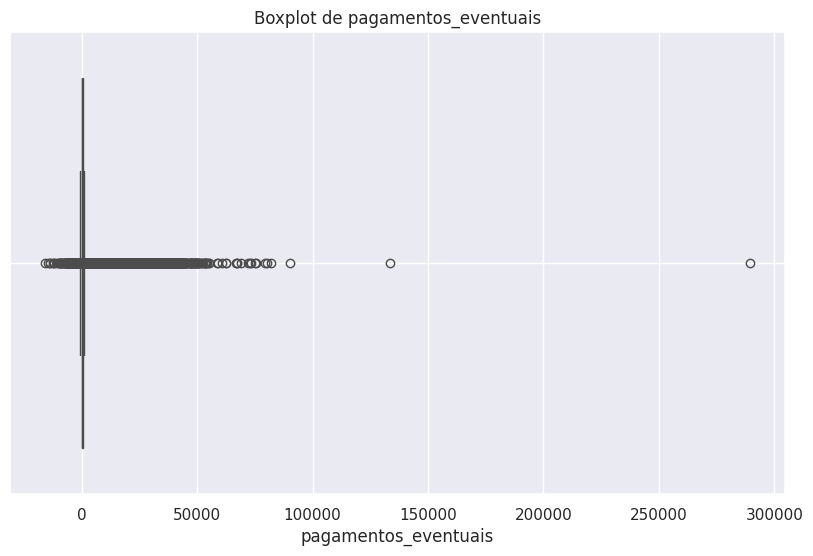

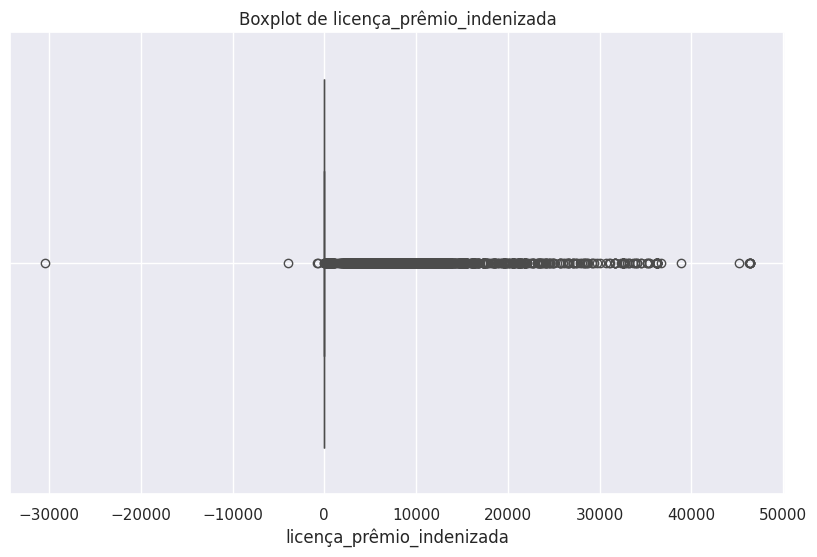

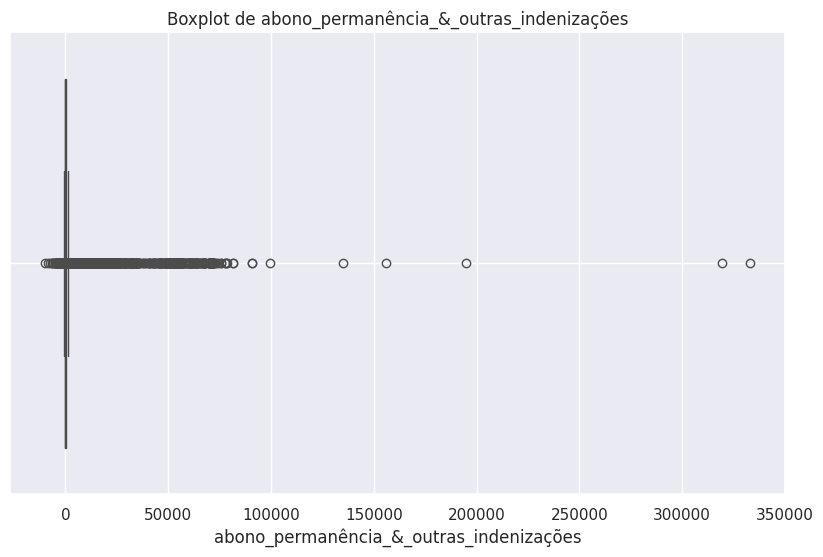

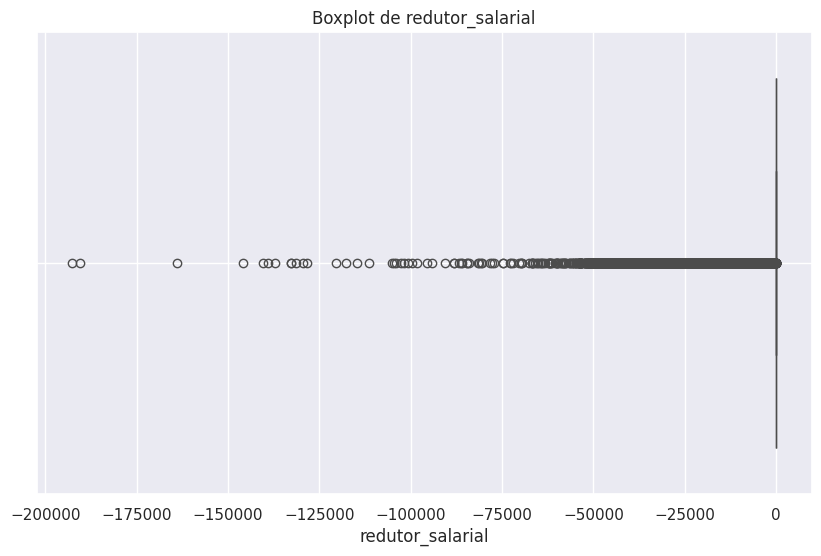

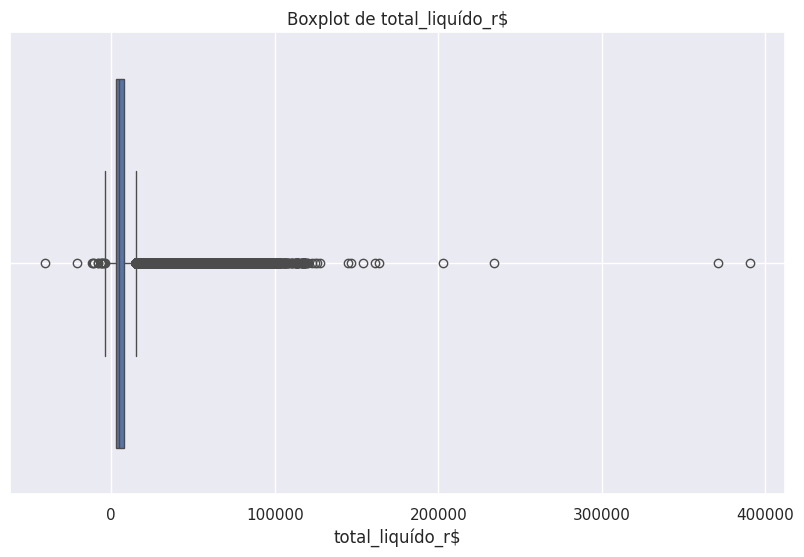

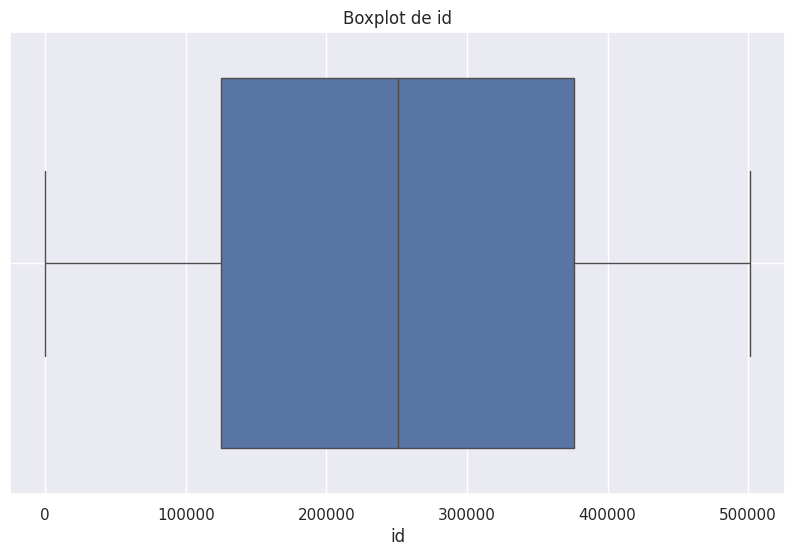

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.boxplot(): Cria um boxplot básico usando matplotlib. O boxplot exibe a mediana, os quartis e possíveis outliers dos dados.
- sns.boxplot(): Cria um boxplot usando seaborn, que oferece uma estética melhor e permite a inclusão de outras variáveis para comparação, se desejado.

Personalização Adicional
- plt.boxplot(): Permite várias personalizações, como adicionar notches (entrecortes) no boxplot para mostrar intervalos de confiança.
- sns.boxplot(): Permite incluir a estética da visualização e pode combinar facilmente com outras variáveis ou facetas.

Esses métodos permitirão visualizar a distribuição, a mediana, e os possíveis outliers para cada variável numérica no seu DataFrame.

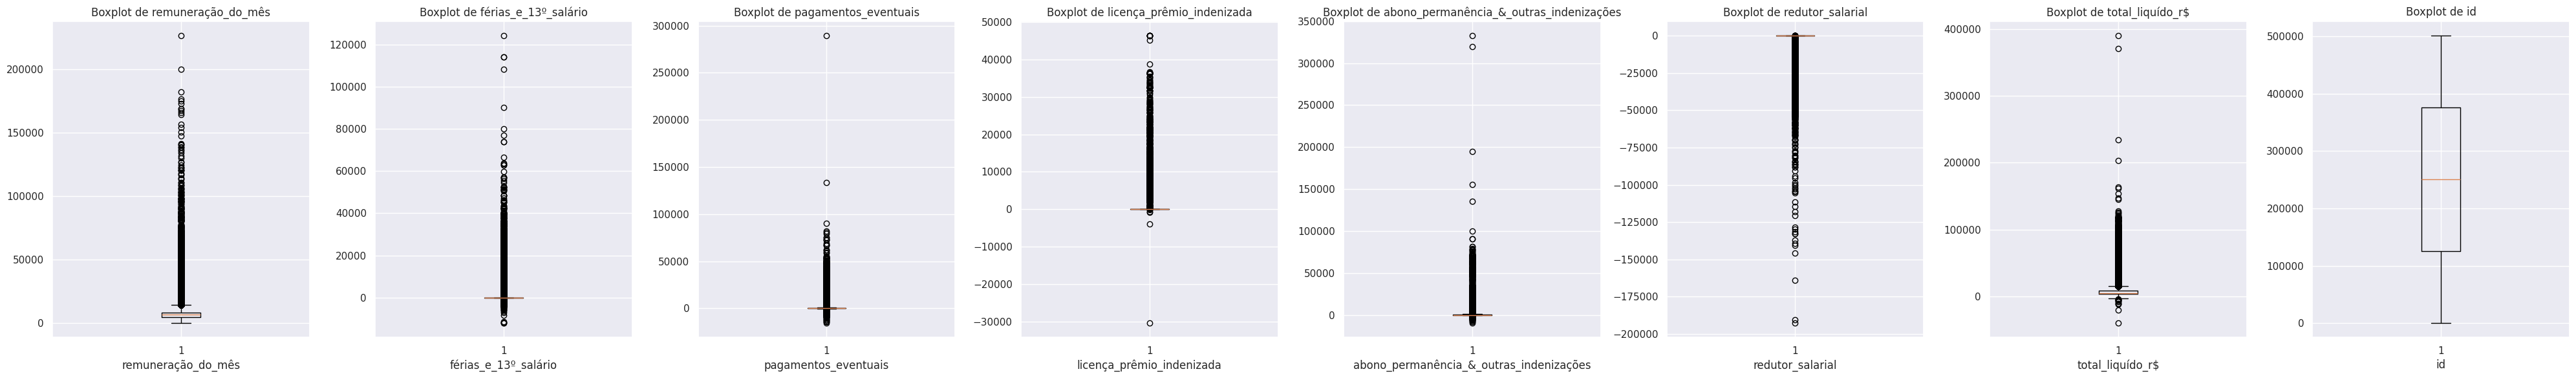

In [36]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.boxplot(numeric_df[column].dropna())
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

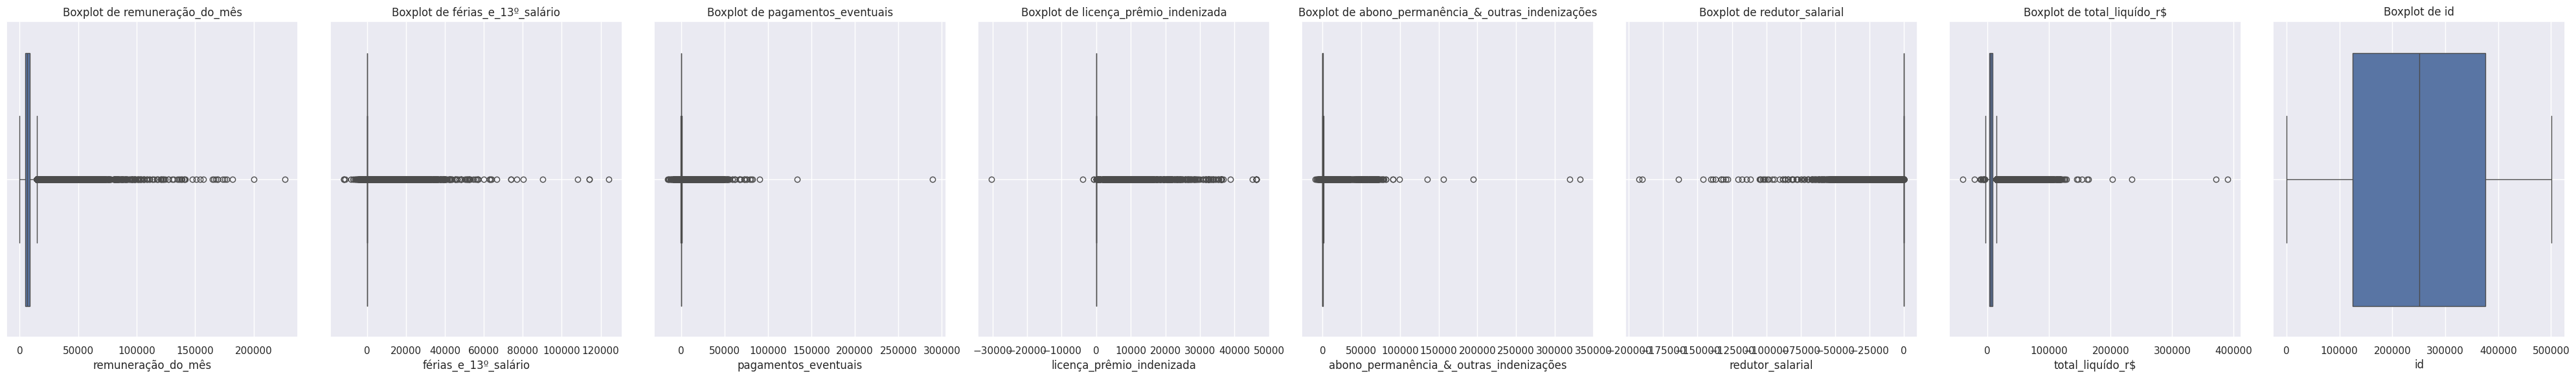

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.boxplot(x=numeric_df[column], ax=ax)
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **4. Discussão**

O que está acontecendo aqui?
Vamos ver:
 - O que acontece com esses salários negativos
 - O que acontece com os salários gigantes

# 4.1. Salários líquidos negativos

Isso deve ser resultado de redutor salarial, não acham?

Ganhou a mais, agora desconta.

In [38]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'redutor_salarial']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,redutor_salarial
56306,-40292.39,0.0
268693,-20634.33,0.0
70185,-11453.49,0.0
249318,-10824.37,0.0
368333,-10525.56,0.0
376377,-8098.01,0.0
387583,-7782.66,0.0
378012,-6274.60,0.0
469815,-6028.17,0.0
485415,-5557.92,0.0


De onde vieram esses salários negativos?

In [39]:
cols = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

df.loc[
    df['total_liquído_r$'] < 0,
    cols
].head(10)

,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
31599,0.00,906.60,3253.72,0.0,-57.65,0.0,-2605.48
43044,2172.20,0.00,-4952.58,0.0,197.87,0.0,-3472.98
53708,1882.07,0.00,-1217.43,0.0,24.15,0.0,-0.48
55675,0.00,466.06,115.93,0.0,0.00,0.0,-1147.66
56198,506.10,0.00,-490.10,0.0,54.35,0.0,-108.21
56306,463.64,0.00,-8272.07,0.0,-1203.80,0.0,-40292.39
60398,2326.63,0.00,-2944.12,0.0,0.00,0.0,-502.24
61175,822.18,0.00,3385.11,0.0,0.00,0.0,-1458.91
70185,218.88,0.00,-13892.28,0.0,24.08,0.0,-11453.49
86587,0.00,287.47,114.99,0.0,0.00,0.0,-659.98


Parece que encontramos, coluna pagamentos_eventuais.

In [40]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'pagamentos_eventuais']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,pagamentos_eventuais
56306,-40292.39,-8272.07
268693,-20634.33,-753.56
70185,-11453.49,-13892.28
249318,-10824.37,-15765.32
368333,-10525.56,-5312.75
376377,-8098.01,-10875.79
387583,-7782.66,-13736.00
378012,-6274.60,-4769.90
469815,-6028.17,-8643.11
485415,-5557.92,-14404.43


Isso é raro… ou é frequente?

In [41]:
(df['total_liquído_r$'] < 0).sum()

np.int64(67)

Vamos olhar a estatística descritiva desses 42 sujeitos:

In [42]:
df[df['total_liquído_r$'] < 0]['total_liquído_r$'].describe()

,total_liquído_r$
count,67.000000
mean,-3191.908657
std,5735.963720
min,-40292.390000
25%,-3010.615000
50%,-1582.650000
75%,-670.150000
max,-0.480000
